# 03. Feature Engineering & RFM Analysis

**CRISP-DM Phase**: Data Preparation → Feature Engineering  
**Mục tiêu**: Tạo các đặc trưng cấp khách hàng phục vụ 3 bài toán chính:

1. **Phân khúc khách hàng** bằng RFM và K-Means (→ notebook 04).
2. **Dự đoán khách hàng mua lại trong 90 ngày** (→ notebook 05).
3. **Chuẩn bị dữ liệu giỏ hàng** cho Association Rules (→ notebook 06).

### Nguyên tắc:
- Không huấn luyện mô hình (K-Means, Logistic Regression, v.v.) trong notebook này.
- Không sử dụng dữ liệu tương lai để tạo đặc trưng (tránh data leakage).
- Không dùng `CustomerID` làm biến đầu vào cho mô hình.
- Dữ liệu gốc (`data/raw/`) không bị thay đổi.


In [14]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    INTERIM_DIR, PROCESSED_DIR,
    FIGURES_FEATURE_ENGINEERING, TABLES_FEATURE_ENGINEERING,
    REPEAT_PURCHASE_WINDOW_DAYS,
)
from src.feature_engineering import (
    build_rfm_features,
    create_rfm_scores,
    assign_rfm_segment,
    summarize_rfm_segments,
    build_repeat_purchase_features,
    build_basket_data,
    summarize_features,
    validate_feature_data,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
%matplotlib inline

print("Import thành công!")


Import thành công!


## 1. Đọc và Chuẩn hóa Customer Data

Sử dụng `data/interim/customer_transactions.csv` — tập dữ liệu giao dịch đã làm sạch, chỉ chứa các dòng có `CustomerID` xác định.


In [15]:
df_cust = pd.read_csv(INTERIM_DIR / 'customer_transactions.csv')
df_cust['InvoiceDate'] = pd.to_datetime(df_cust['InvoiceDate'])
df_cust['CustomerID'] = df_cust['CustomerID'].astype(int)
df_cust['InvoiceNo'] = df_cust['InvoiceNo'].astype(str)
df_cust['StockCode'] = df_cust['StockCode'].astype(str)

# Kiểm tra cột bắt buộc
required_cols = ['InvoiceNo', 'StockCode', 'Description', 'Quantity',
                 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']
assert all(c in df_cust.columns for c in required_cols), 'Thiếu cột!'

# Kiểm tra dữ liệu hợp lệ
assert df_cust['CustomerID'].isnull().sum() == 0
assert (df_cust['Quantity'] > 0).all()
assert (df_cust['UnitPrice'] > 0).all()
assert (df_cust['TotalAmount'] > 0).all()

print(f"Số dòng                : {len(df_cust):,}")
print(f"Số khách hàng          : {df_cust['CustomerID'].nunique():,}")
print(f"Số hóa đơn             : {df_cust['InvoiceNo'].nunique():,}")
print(f"Số sản phẩm            : {df_cust['StockCode'].nunique():,}")
print(f"Ngày nhỏ nhất          : {df_cust['InvoiceDate'].min()}")
print(f"Ngày lớn nhất          : {df_cust['InvoiceDate'].max()}")
print(f"Tổng doanh thu         : {df_cust['TotalAmount'].sum():,.2f} GBP")
print(f"Tổng số lượng sản phẩm : {df_cust['Quantity'].sum():,}")

df_cust.head()


Số dòng                : 391,153
Số khách hàng          : 4,334
Số hóa đơn             : 18,402
Số sản phẩm            : 3,660
Ngày nhỏ nhất          : 2010-12-01 08:26:00
Ngày lớn nhất          : 2011-12-09 12:50:00
Tổng doanh thu         : 8,737,227.64 GBP
Tổng số lượng sản phẩm : 5,141,787


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,IsCancelled,IsAdjust,IsDuplicate,IsQuantityInvalid,IsPriceInvalid,IsQuantityOutlier,IsPriceOutlier,IsAmountOutlier
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False,False,False,False,False,False,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,False,False,False,False,False,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False,False,False,False,False,False,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,False,False,False,False,False,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,False,False,False,False,False,False,False


## 2. Tạo RFM Customer Features

### Định nghĩa:
- **Recency** = `reference_date − LastPurchaseDate` (ngày). Giá trị nhỏ → khách mua gần đây.
- **Frequency** = Số hóa đơn (`InvoiceNo`) khác nhau. **Không** đếm số dòng giao dịch.
- **Monetary** = Tổng `TotalAmount`.
- **reference_date** = `max(InvoiceDate) + 1 ngày`.

### Các biến mở rộng:
`TotalItems`, `UniqueProducts`, `UniqueInvoices`, `ActiveDays`, `AverageOrderValue`, `AverageItemsPerInvoice`, `CustomerLifetimeDays`, `Country`.


In [16]:
rfm, reference_date = build_rfm_features(df_cust)

print(f"reference_date    : {reference_date}")
print(f"Số khách hàng RFM : {len(rfm):,}")
print(f"\nThống kê mô tả RFM:")
rfm[['Recency', 'Frequency', 'Monetary', 'TotalItems', 'UniqueProducts',
     'AverageOrderValue', 'CustomerLifetimeDays']].describe().round(2)


reference_date    : 2011-12-10 12:50:00
Số khách hàng RFM : 4,334

Thống kê mô tả RFM:


,Recency,Frequency,Monetary,TotalItems,UniqueProducts,AverageOrderValue,CustomerLifetimeDays
count,"4,334.00","4,334.00","4,334.00","4,334.00","4,334.00","4,334.00","4,334.00"
mean,92.70,4.25,"2,015.97","1,186.38",61.43,415.48,130.29
std,100.18,7.63,"8,903.67","5,040.62",85.31,"1,800.90",132.09
min,1.00,1.00,3.75,1.00,1.00,3.75,0.00
25%,18.00,1.00,304.24,159.25,16.00,177.20,0.00
50%,51.00,2.00,662.56,377.50,35.00,289.56,92.00
75%,143.00,5.00,"1,631.62",989.75,77.00,423.41,252.00
max,374.00,206.00,"279,138.02","196,844.00","1,785.00","84,236.25",373.00


## 3. Tạo RFM Score và RFM Segment

### Điểm RFM (1–5):
- **R_Score**: Recency thấp → điểm cao (khách mới mua gần đây tốt hơn).
- **F_Score**: Frequency cao → điểm cao.
- **M_Score**: Monetary cao → điểm cao.

Sử dụng `pd.qcut` với xử lý `duplicates='drop'` và fallback `rank(method='first')` để tránh lỗi khi nhiều khách có cùng giá trị.

### Phân khúc RFM mô tả:
| Phân khúc | Logic phân loại |
|---|---|
| Champions | R ≥ 4 AND F ≥ 4 AND M ≥ 4 |
| Loyal Customers | F ≥ 4 AND M ≥ 3 |
| Big Spenders | M ≥ 4 |
| Recent Customers | R ≥ 4 AND F ≤ 2 |
| At Risk | R ≤ 2 AND F ≥ 2 |
| Regular Customers | Tất cả trường hợp còn lại |

> **Lưu ý**: Đây là phân khúc mô tả dựa trên điểm RFM. Sẽ được kiểm chứng và so sánh bằng K-Means clustering ở notebook 04.


In [17]:
rfm = create_rfm_scores(rfm)
rfm['RFM_Segment'] = rfm.apply(assign_rfm_segment, axis=1)

print("Phân bố R_Score:")
print(rfm['R_Score'].value_counts().sort_index())
print("\nPhân bố F_Score:")
print(rfm['F_Score'].value_counts().sort_index())
print("\nPhân bố M_Score:")
print(rfm['M_Score'].value_counts().sort_index())

# Lưu
rfm.to_csv(PROCESSED_DIR / 'rfm_customer_features.csv', index=False)
print(f"\nĐã lưu: {PROCESSED_DIR / 'rfm_customer_features.csv'}")
print(f"Kích thước: {len(rfm):,} dòng x {len(rfm.columns)} cột")

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
     'M_Score', 'RFM_Score', 'RFM_Code', 'RFM_Segment']].head(10)


Phân bố R_Score:
R_Score
1    867
2    838
3    860
4    888
5    881
Name: count, dtype: int64

Phân bố F_Score:
F_Score
1    867
2    867
3    867
4    867
5    866
Name: count, dtype: int64

Phân bố M_Score:
M_Score
1    867
2    867
3    866
4    867
5    867
Name: count, dtype: int64

Đã lưu: D:\Data-mininng\data\processed\rfm_customer_features.csv
Kích thước: 4,334 dòng x 20 cột


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Code,RFM_Segment
0,12346,326,1,"77,183.60",1,1,5,7,115,Big Spenders
1,12347,2,7,"4,310.00",5,5,5,15,555,Champions
2,12348,75,4,"1,437.24",2,4,4,10,244,Loyal Customers
3,12349,19,1,"1,457.55",4,1,4,9,414,Big Spenders
4,12350,310,1,294.40,1,1,2,4,112,Regular Customers
5,12352,36,7,"1,385.74",3,5,4,12,354,Loyal Customers
6,12353,204,1,89.00,1,1,1,3,111,Regular Customers
7,12354,232,1,"1,079.40",1,1,4,6,114,Big Spenders
8,12355,214,1,459.40,1,1,2,4,112,Regular Customers
9,12356,23,3,"2,487.43",4,3,5,12,435,Big Spenders


## 4. Tổng Hợp Phân Khúc RFM

In [18]:
segment_summary = summarize_rfm_segments(rfm)
segment_summary.to_csv(TABLES_FEATURE_ENGINEERING / 'rfm_segment_summary.csv', index=False)
segment_summary


,RFM_Segment,CustomerCount,AverageRecency,AverageFrequency,AverageMonetary,TotalMonetary,AverageOrderValue,CustomerPercent
0,Regular Customers,1249,116.28,1.48,357.17,"446,101.71",263.20,28.82
1,Champions,955,12.81,11.06,"5,973.96","5,705,131.09",462.78,22.04
2,At Risk,777,198.78,1.64,365.26,"283,808.29",239.63,17.93
3,Loyal Customers,692,71.71,5.16,"1,889.15","1,307,289.52",356.94,15.97
4,Big Spenders,371,93.84,2.14,"2,435.39","903,529.78","1,400.30",8.56
5,Recent Customers,290,18.71,1.19,315.06,"91,367.25",266.57,6.69


## 5. Chuẩn Bị Feature Cho Customer Clustering

Tạo file `data/processed/rfm_clustering_features.csv` chứa:
- Các biến RFM gốc: `Recency`, `Frequency`, `Monetary`, `TotalItems`, `UniqueProducts`, `AverageOrderValue`, `CustomerLifetimeDays`.
- Các biến log-transform: `Log_Recency`, `Log_Frequency`, `Log_Monetary` (vì phân phối lệch phải).

> `CustomerID` được giữ để nối kết quả cluster sau này, nhưng **KHÔNG** được sử dụng làm biến đầu vào cho K-Means.

> Việc chọn số cụm K bằng Elbow Method và Silhouette Score sẽ thực hiện trong notebook 04.


In [19]:
clustering_cols = ['CustomerID', 'Recency', 'Frequency', 'Monetary',
                   'TotalItems', 'UniqueProducts', 'AverageOrderValue',
                   'CustomerLifetimeDays']
rfm_cluster = rfm[clustering_cols].copy()

rfm_cluster['Log_Recency'] = np.log1p(rfm_cluster['Recency'])
rfm_cluster['Log_Frequency'] = np.log1p(rfm_cluster['Frequency'])
rfm_cluster['Log_Monetary'] = np.log1p(rfm_cluster['Monetary'])

rfm_cluster.to_csv(PROCESSED_DIR / 'rfm_clustering_features.csv', index=False)
print(f"Đã lưu: {PROCESSED_DIR / 'rfm_clustering_features.csv'}")
print(f"Kích thước: {len(rfm_cluster):,} dòng x {len(rfm_cluster.columns)} cột")
print(f"Các cột: {list(rfm_cluster.columns)}")

rfm_cluster.describe().round(2)


Đã lưu: D:\Data-mininng\data\processed\rfm_clustering_features.csv
Kích thước: 4,334 dòng x 11 cột
Các cột: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalItems', 'UniqueProducts', 'AverageOrderValue', 'CustomerLifetimeDays', 'Log_Recency', 'Log_Frequency', 'Log_Monetary']


,Recency,Frequency,Monetary,TotalItems,UniqueProducts,AverageOrderValue,CustomerLifetimeDays,Log_Recency,Log_Frequency,Log_Monetary
count,"4,334.00","4,334.00","4,334.00","4,334.00","4,334.00","4,334.00","4,334.00","4,334.00","4,334.00","4,334.00"
mean,92.70,4.25,"2,015.97","1,186.38",61.43,415.48,130.29,3.83,1.34,6.58
std,100.18,7.63,"8,903.67","5,040.62",85.31,"1,800.90",132.09,1.34,0.68,1.26
min,1.00,1.00,3.75,1.00,1.00,3.75,0.00,0.69,0.69,1.56
25%,18.00,1.00,304.24,159.25,16.00,177.20,0.00,2.94,0.69,5.72
50%,51.00,2.00,662.56,377.50,35.00,289.56,92.00,3.95,1.10,6.50
75%,143.00,5.00,"1,631.62",989.75,77.00,423.41,252.00,4.97,1.79,7.40
max,374.00,206.00,"279,138.02","196,844.00","1,785.00","84,236.25",373.00,5.93,5.33,12.54


## 6. Tạo Nhãn `repeat_purchase_90d` (Tránh Data Leakage)

### Chiến lược tách thời gian:
```
|←── Feature period ──→|←── Label window (90 ngày) ──→|
                    cutoff_date                    max_date
```

- `cutoff_date = max_date − 90 ngày`
- **Feature**: Chỉ tính từ giao dịch **trước hoặc bằng** `cutoff_date`.
- **Label**: Kiểm tra giao dịch trong **(cutoff_date, cutoff_date + 90 ngày]**.
- `repeat_purchase_90d = 1` nếu khách có ít nhất 1 hóa đơn khác nhau trong cửa sổ label.

### Điều tuyệt đối KHÔNG được làm:
- Dùng toàn bộ lịch sử đến `max_date` để tạo feature.
- Đưa `future_invoice_count` hoặc `future_revenue` vào file modeling.
- Dùng ngày mua trong tương lai làm Recency.


In [20]:
repeat_features, audit_df, repeat_info = build_repeat_purchase_features(df_cust)

print(f"max_date          : {repeat_info['max_date']}")
print(f"cutoff_date       : {repeat_info['cutoff_date']}")
print(f"feature_ref_date  : {repeat_info['feature_ref_date']}")
print(f"window_days       : {repeat_info['window_days']}")
print(f"Khách có lịch sử  : {repeat_info['customers_with_history']:,}")
print(f"Khách tạo label   : {repeat_info['customers_in_features']:,}")
print(f"Label 1 (mua lại) : {repeat_info['label_1_count']:,}")
print(f"Label 0 (không)   : {repeat_info['label_0_count']:,}")
print(f"Tỷ lệ mua lại    : {repeat_info['repeat_rate']:.2f}%")

# Kiểm tra data leakage
assert 'future_invoice_count' not in repeat_features.columns, 'DATA LEAKAGE!'
assert 'future_revenue' not in repeat_features.columns, 'DATA LEAKAGE!'
print("\n[OK] Không có data leakage!")

repeat_features.to_csv(PROCESSED_DIR / 'repeat_purchase_features.csv', index=False)
print(f"Đã lưu: {PROCESSED_DIR / 'repeat_purchase_features.csv'}")
print(f"Kích thước: {len(repeat_features):,} dòng x {len(repeat_features.columns)} cột")
print(f"Các cột: {list(repeat_features.columns)}")


max_date          : 2011-12-09 12:50:00
cutoff_date       : 2011-09-10 12:50:00
feature_ref_date  : 2011-09-11 12:50:00
window_days       : 90
Khách có lịch sử  : 3,368
Khách tạo label   : 3,368
Label 1 (mua lại) : 1,919
Label 0 (không)   : 1,449
Tỷ lệ mua lại    : 56.98%

[OK] Không có data leakage!
Đã lưu: D:\Data-mininng\data\processed\repeat_purchase_features.csv
Kích thước: 3,368 dòng x 13 cột
Các cột: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalItems', 'UniqueProducts', 'UniqueInvoices', 'ActiveDays', 'Country', 'AverageOrderValue', 'AverageItemsPerInvoice', 'CustomerLifetimeDays', 'repeat_purchase_90d']


## 7. Kiểm Tra Mất Cân Bằng Nhãn

In [21]:
# Audit
audit_df.to_csv(TABLES_FEATURE_ENGINEERING / 'repeat_purchase_label_audit.csv', index=False)

# Class balance
class_balance = repeat_features['repeat_purchase_90d'].value_counts().reset_index()
class_balance.columns = ['repeat_purchase_90d', 'Count']
class_balance['Percentage'] = round(class_balance['Count'] / class_balance['Count'].sum() * 100, 2)
class_balance.to_csv(TABLES_FEATURE_ENGINEERING / 'repeat_purchase_class_balance.csv', index=False)

print("Class Balance:")
display(class_balance)

if class_balance['Percentage'].min() < 30:
    print("\n⚠️ Dữ liệu mất cân bằng. Bước modeling cần cân nhắc:")
    print("  - Stratified train/test split")
    print("  - Class weight")
    print("  - Đánh giá bằng Precision, Recall, F1, ROC-AUC, PR-AUC")
else:
    print("\n✅ Phân bố nhãn tương đối cân bằng.")


Class Balance:


,repeat_purchase_90d,Count,Percentage
0,1,1919,56.98
1,0,1449,43.02



✅ Phân bố nhãn tương đối cân bằng.


## 8. Chuẩn Bị Basket Data Cho Association Rules

Sử dụng `data/interim/product_transactions.csv` (đã loại bỏ mã phi sản phẩm và gift voucher).

Quy tắc:
- Mỗi `InvoiceNo` = 1 giao dịch.
- Mỗi `StockCode` chỉ xuất hiện 1 lần trong mỗi hóa đơn.
- Dùng `StockCode` làm item ID; giữ `Description` để tra cứu.


In [22]:
df_prod = pd.read_csv(INTERIM_DIR / 'product_transactions.csv')
basket_long, basket_stats = build_basket_data(df_prod)

print(f"Tổng số dòng basket        : {basket_stats['total_rows']:,}")
print(f"Số hóa đơn duy nhất        : {basket_stats['unique_invoices']:,}")
print(f"Số sản phẩm duy nhất       : {basket_stats['unique_products']:,}")
print(f"TB sản phẩm/hóa đơn        : {basket_stats['avg_items_per_invoice']:.2f}")

basket_long.to_csv(PROCESSED_DIR / 'association_basket_long.csv', index=False)
print(f"\nĐã lưu: {PROCESSED_DIR / 'association_basket_long.csv'}")

# Tạo one-hot matrix nếu kích thước hợp lý
n_inv = basket_stats['unique_invoices']
n_prod = basket_stats['unique_products']
matrix_size_gb = n_inv * n_prod * 1 / (1024**3)
print(f"Kích thước one-hot ước tính: {n_inv:,} x {n_prod:,} = {matrix_size_gb:.2f} GB")

if matrix_size_gb < 1.0:
    basket_matrix = basket_long.pivot_table(
        index='InvoiceNo', columns='StockCode',
        values='Description', aggfunc='count', fill_value=0
    )
    basket_matrix = (basket_matrix > 0).astype(int)
    basket_matrix.to_csv(PROCESSED_DIR / 'association_basket_matrix.csv')
    print(f"Đã lưu ma trận one-hot: {basket_matrix.shape[0]:,} hóa đơn x {basket_matrix.shape[1]:,} sản phẩm")
else:
    print(f"Ma trận quá lớn ({matrix_size_gb:.2f} GB), chỉ lưu dạng dài.")


Tổng số dòng basket        : 517,292
Số hóa đơn duy nhất        : 19,773
Số sản phẩm duy nhất       : 3,908
TB sản phẩm/hóa đơn        : 26.16

Đã lưu: D:\Data-mininng\data\processed\association_basket_long.csv
Kích thước one-hot ước tính: 19,773 x 3,908 = 0.07 GB
Đã lưu ma trận one-hot: 19,773 hóa đơn x 3,908 sản phẩm


## 9. Trực Quan Hóa

### 9.1. Phân phối Recency, Frequency, Monetary


=== 9.1. Phân phối RFM ===


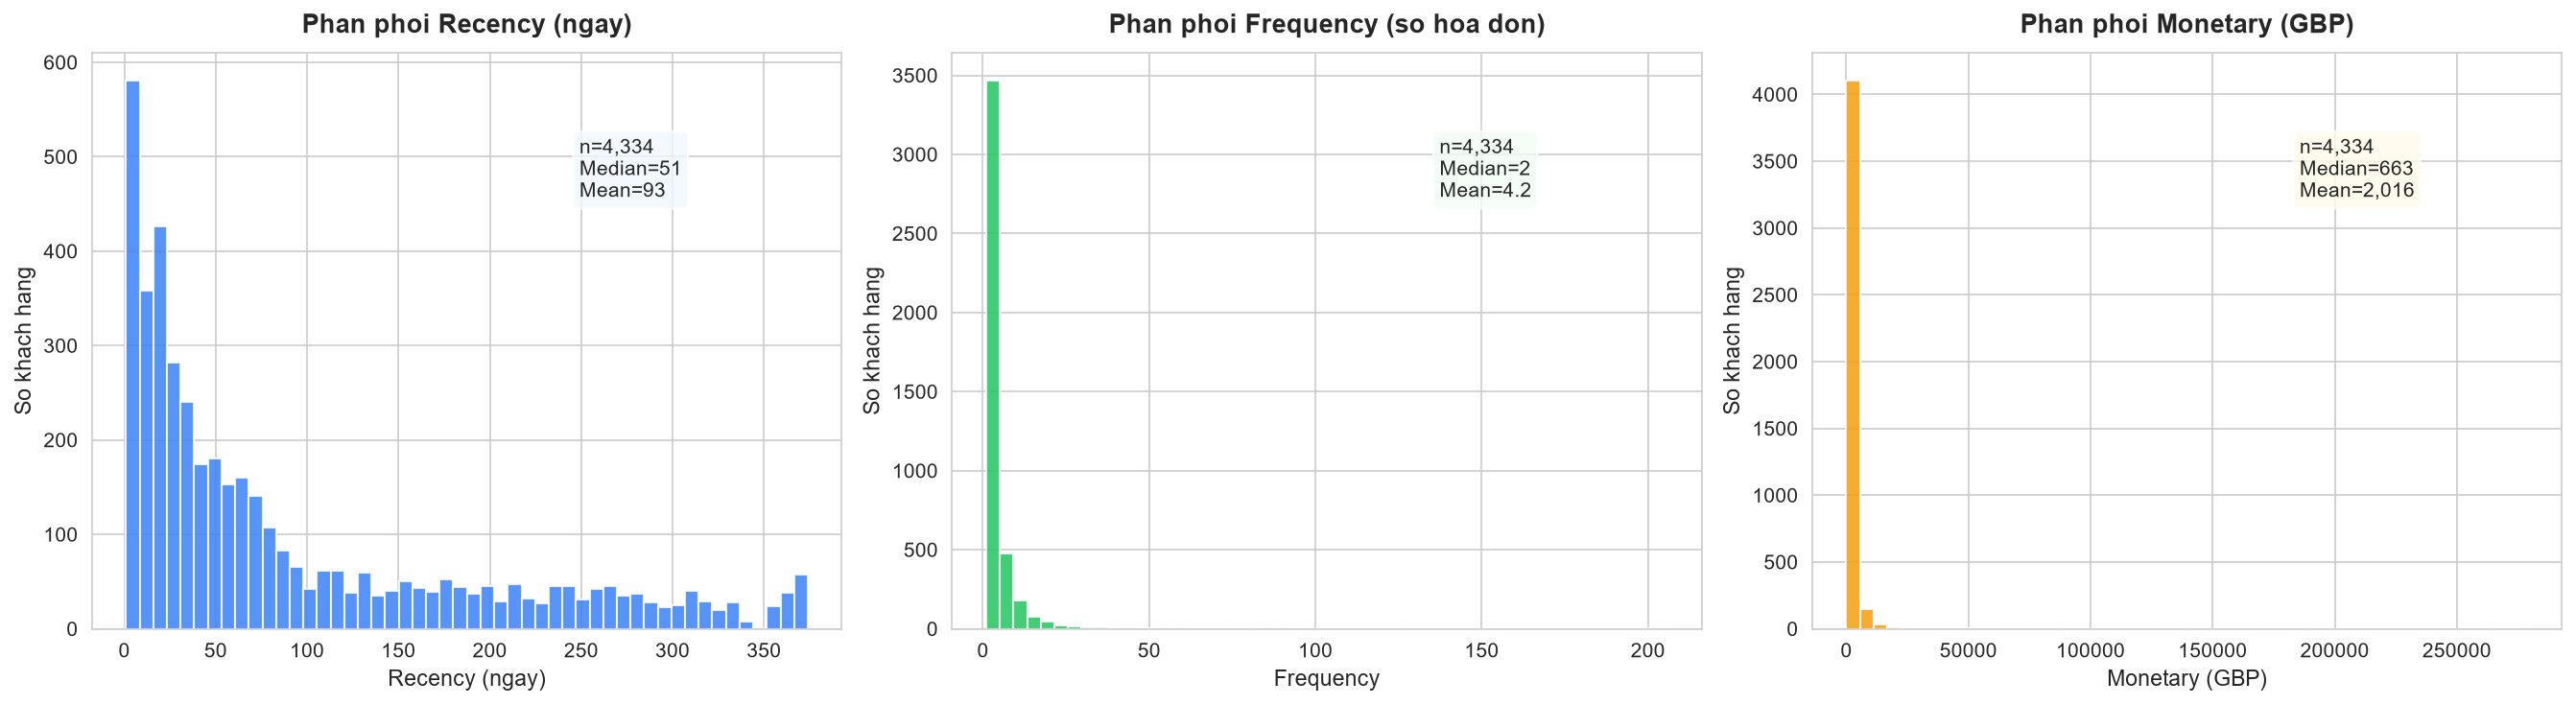

=== 9.2. Phân phối RFM Score ===


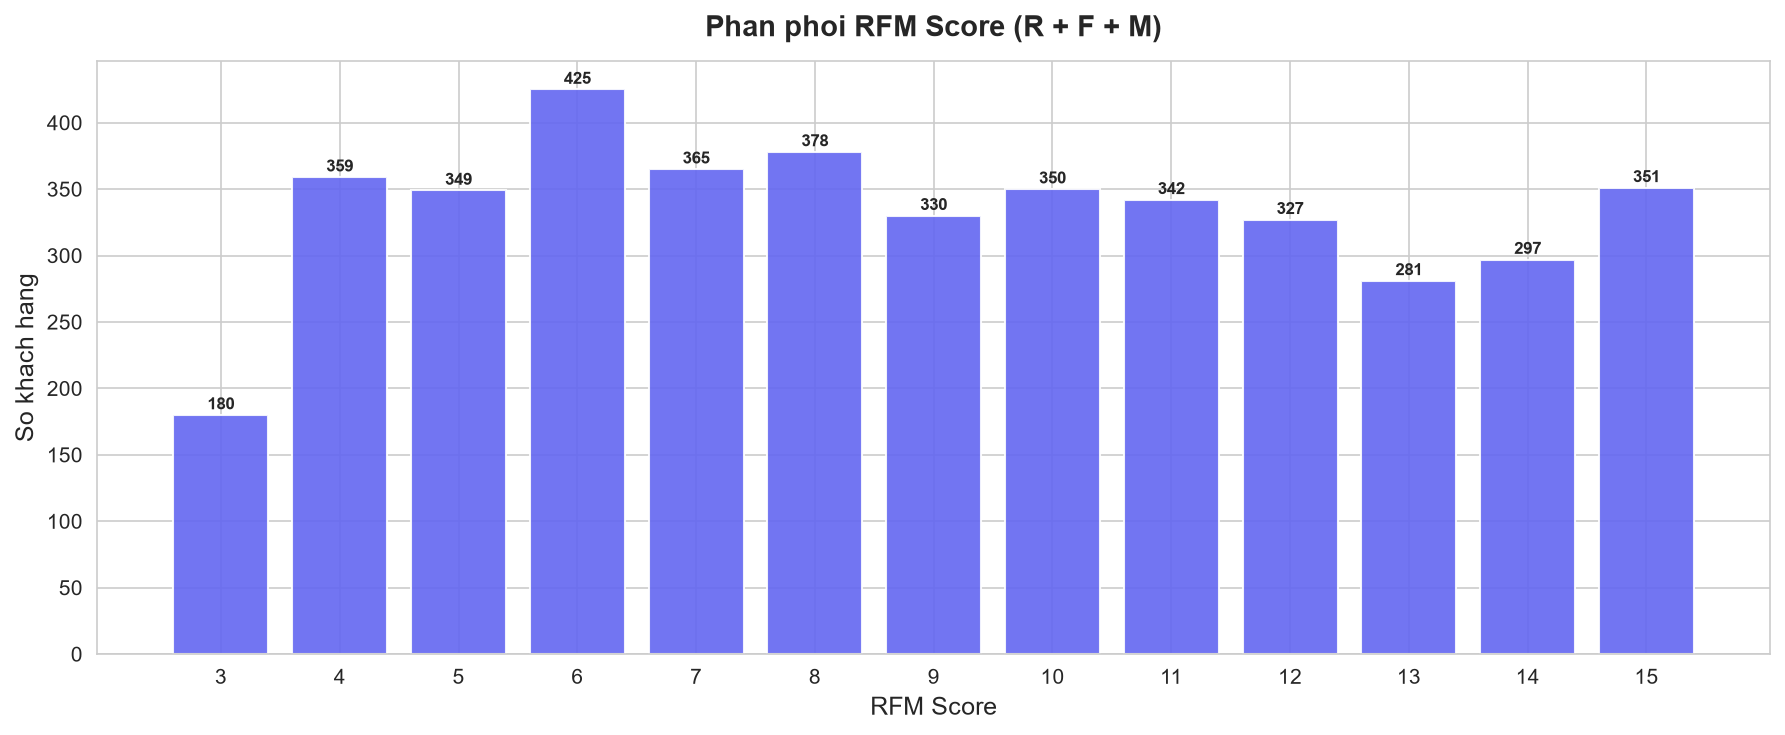

=== 9.3. Phân khúc RFM: Số khách hàng & Doanh thu ===


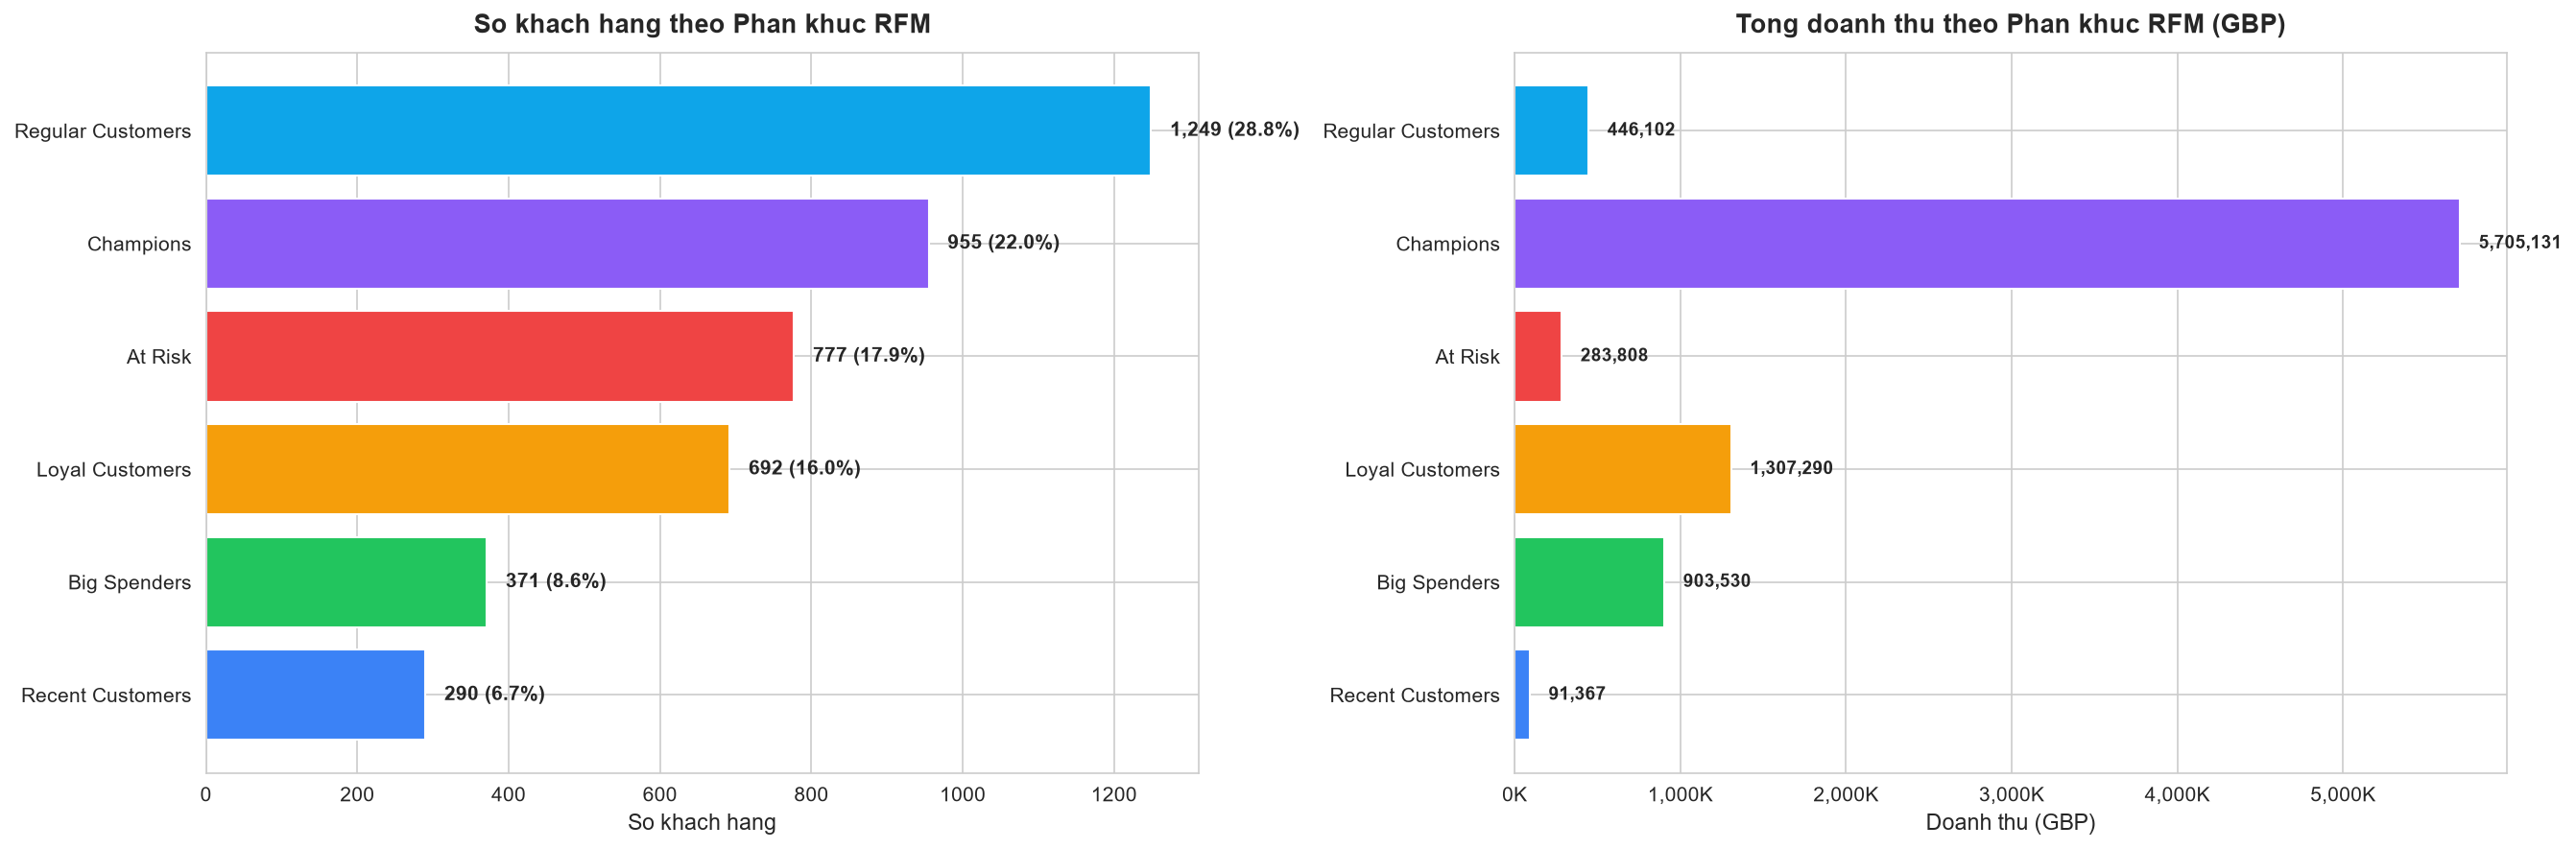

=== 9.4. Tỷ lệ nhãn repeat_purchase_90d ===


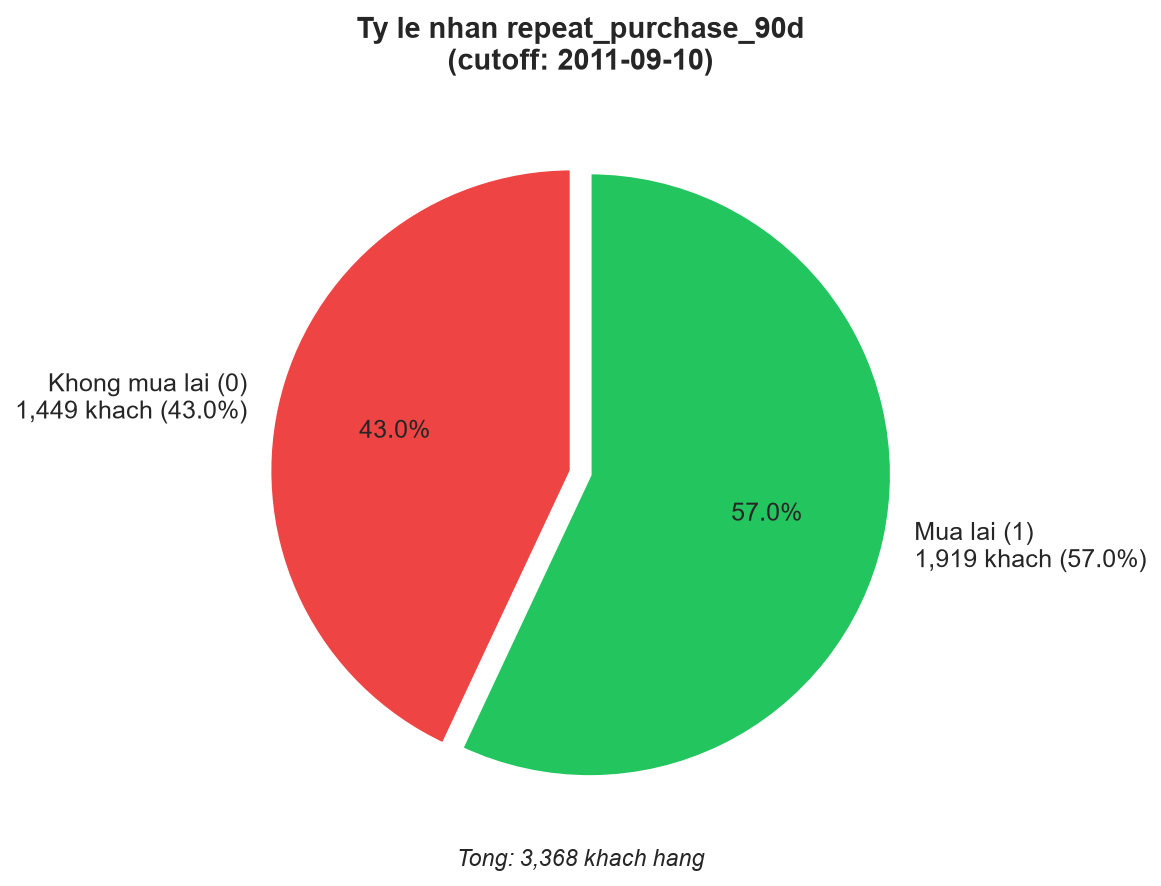

=== 9.5. Ma trận tương quan RFM ===


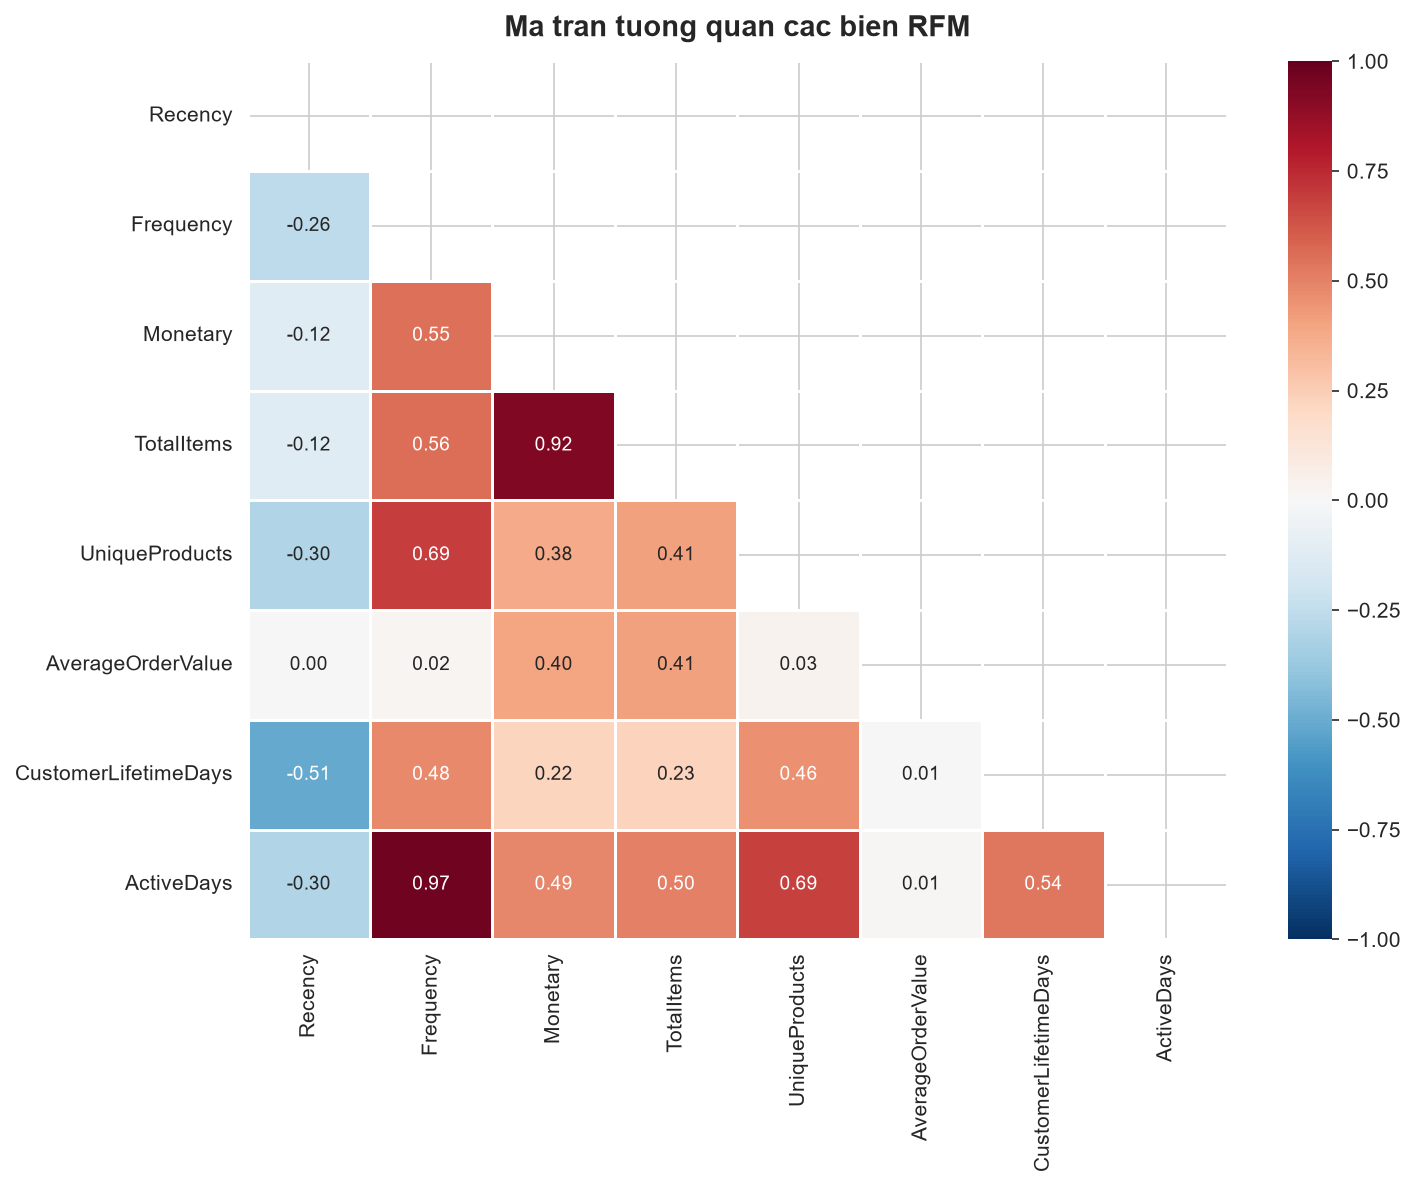

=== 9.6. So sánh trước & sau Log-Transform ===


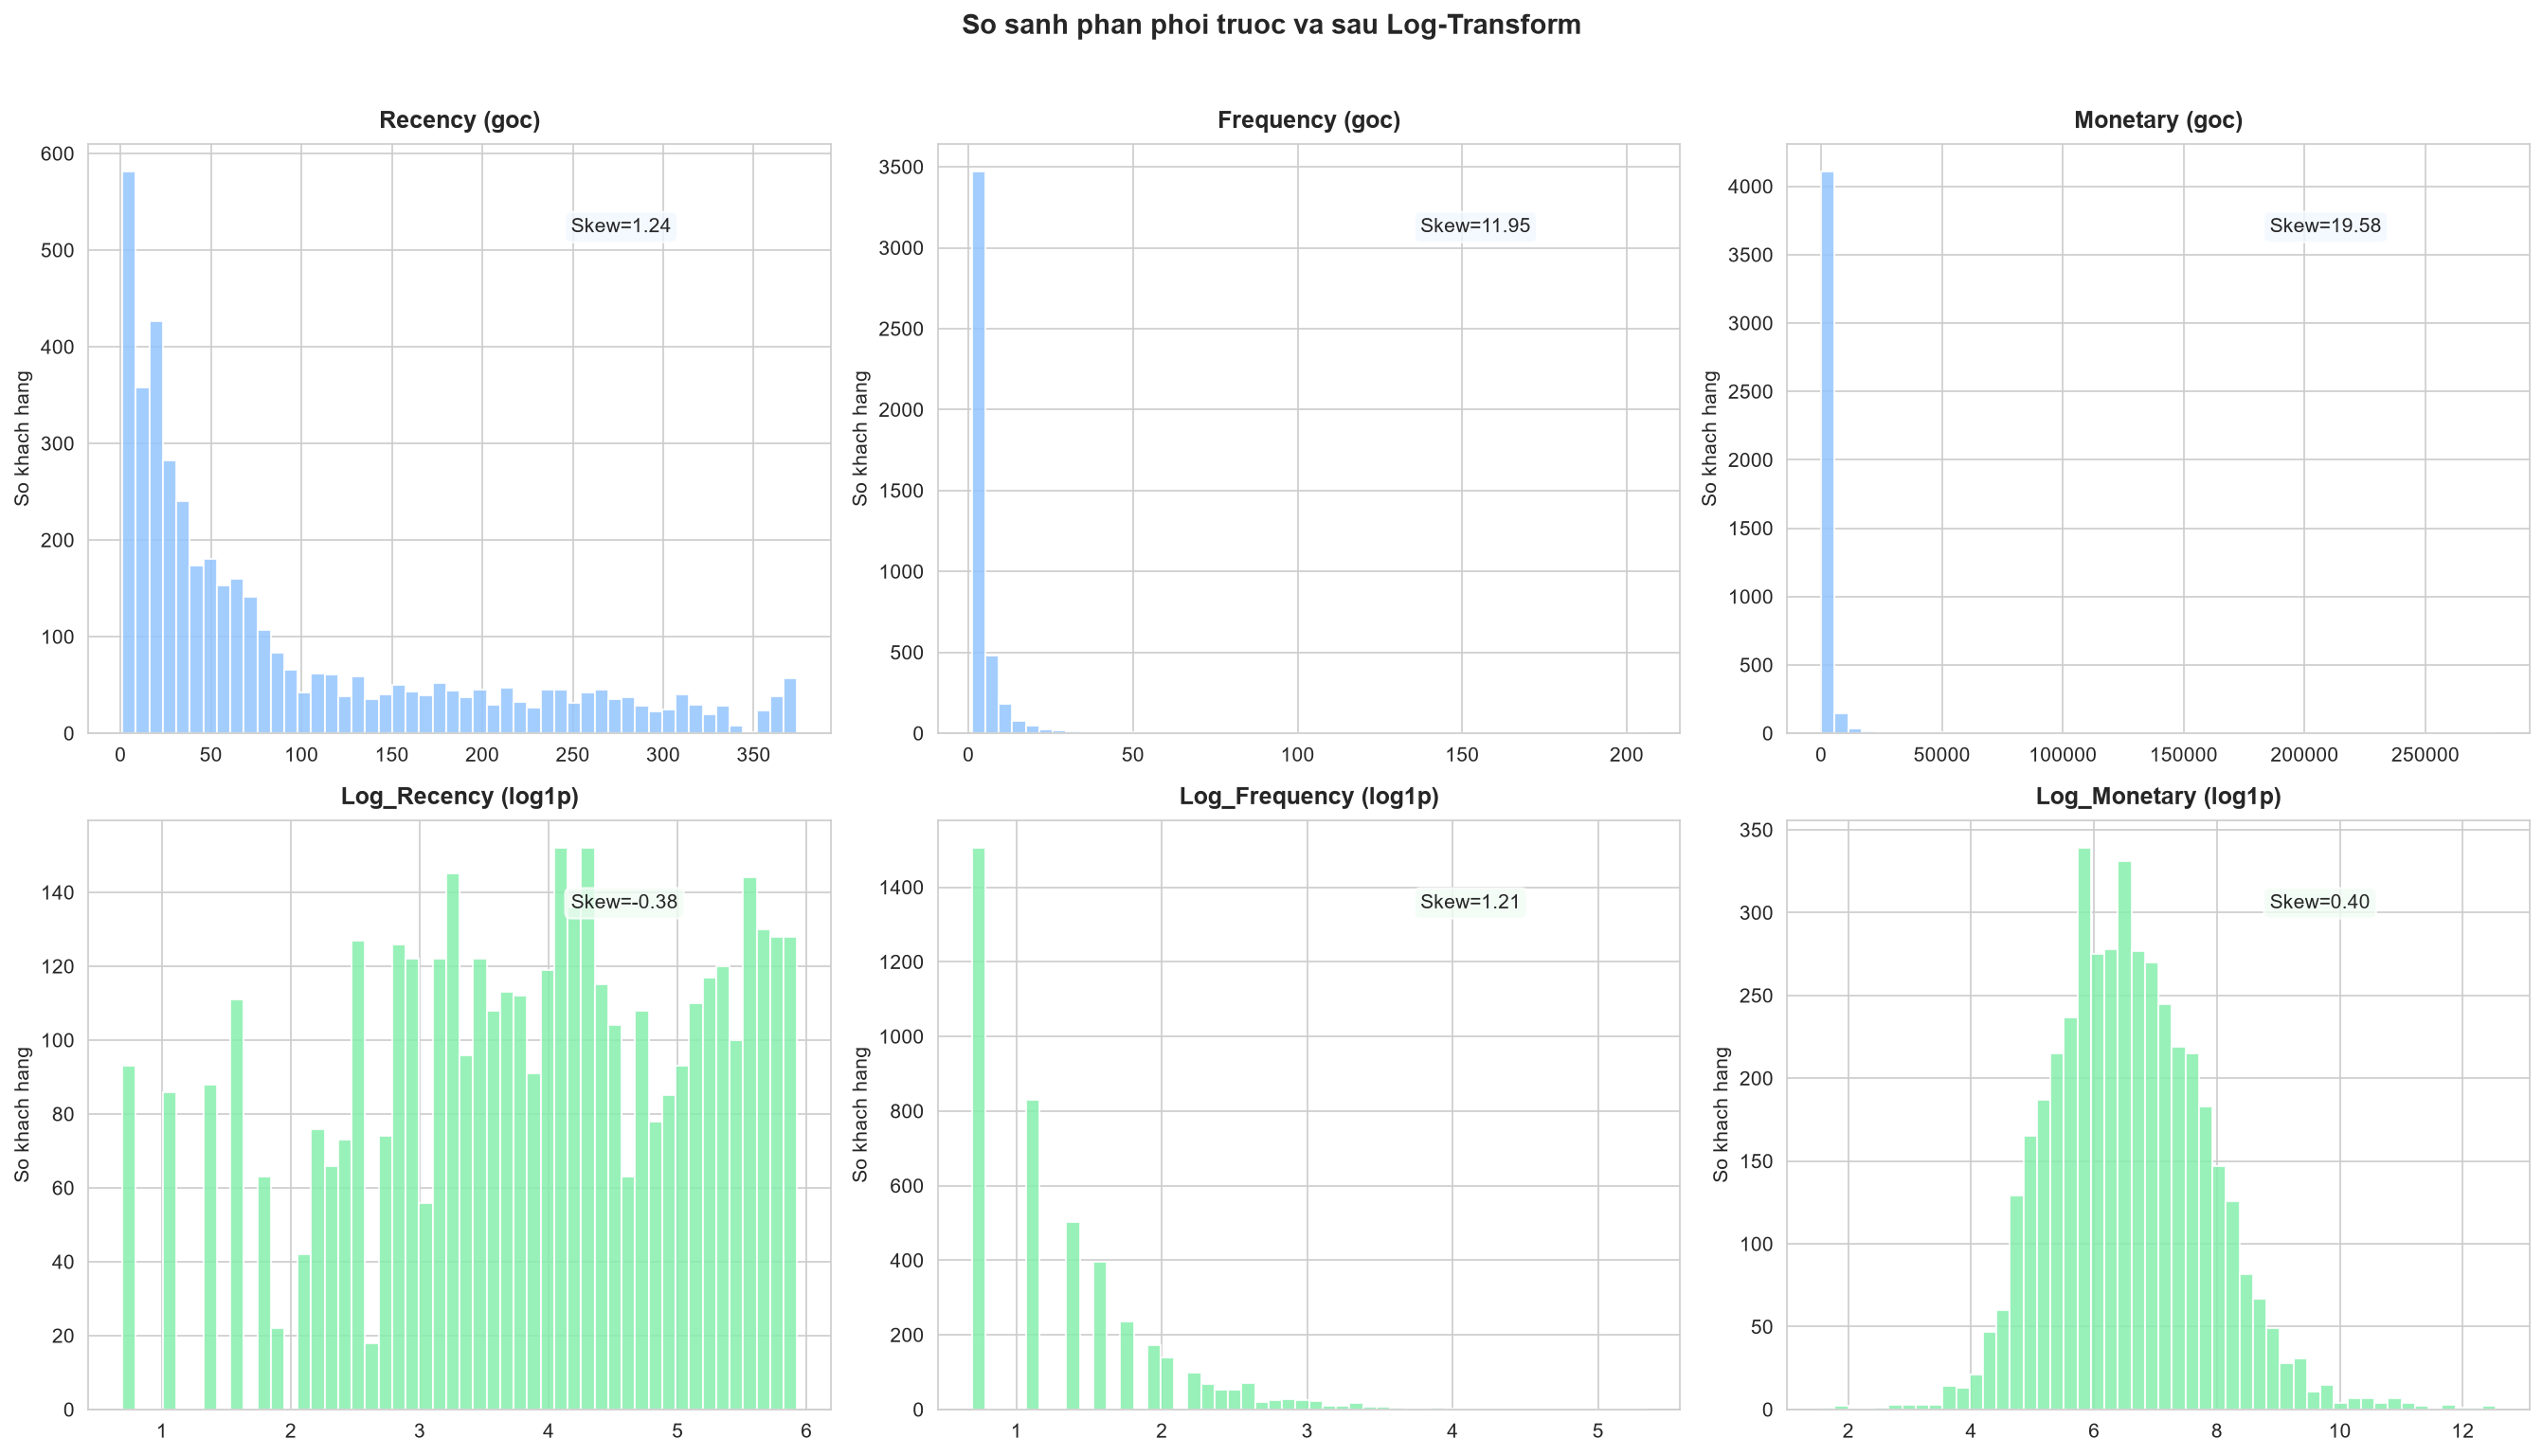

In [23]:
from IPython.display import Image, display as ipy_display

# Hiển thị biểu đồ đã tạo sẵn từ pipeline
figures = [
    ('9.1. Phân phối RFM', FIGURES_FEATURE_ENGINEERING / 'rfm_distribution.png'),
    ('9.2. Phân phối RFM Score', FIGURES_FEATURE_ENGINEERING / 'rfm_score_distribution.png'),
    ('9.3. Phân khúc RFM: Số khách hàng & Doanh thu', FIGURES_FEATURE_ENGINEERING / 'rfm_segment_overview.png'),
    ('9.4. Tỷ lệ nhãn repeat_purchase_90d', FIGURES_FEATURE_ENGINEERING / 'repeat_purchase_label_balance.png'),
    ('9.5. Ma trận tương quan RFM', FIGURES_FEATURE_ENGINEERING / 'rfm_correlation_matrix.png'),
    ('9.6. So sánh trước & sau Log-Transform', FIGURES_FEATURE_ENGINEERING / 'rfm_log_transform_comparison.png'),
]

for title, fpath in figures:
    print(f"=== {title} ===")
    if fpath.exists():
        ipy_display(Image(filename=str(fpath)))
    else:
        print(f"  File chưa tồn tại: {fpath}")


## 10. Feature Summary

In [24]:
rfm_summary = summarize_features(rfm)
rfm_summary.to_csv(TABLES_FEATURE_ENGINEERING / 'feature_summary.csv', index=False)
display(rfm_summary)

# Tổng kết toàn diện Feature Engineering (feature_engineering_summary.csv)
fe_summary = pd.DataFrame([
    {'Metric': 'Customer count (input)', 'Value': str(df_cust['CustomerID'].nunique())},
    {'Metric': 'reference_date', 'Value': str(reference_date)},
    {'Metric': 'cutoff_date', 'Value': str(repeat_info['cutoff_date'])},
    {'Metric': 'Customers with RFM features', 'Value': str(len(rfm))},
    {'Metric': 'Customers eligible for label', 'Value': str(repeat_info['customers_in_features'])},
    {'Metric': 'Label 1 count', 'Value': str(repeat_info['label_1_count'])},
    {'Metric': 'Label 0 count', 'Value': str(repeat_info['label_0_count'])},
    {'Metric': 'Repeat purchase rate (%)', 'Value': str(repeat_info['repeat_rate'])},
    {'Metric': 'RFM feature count', 'Value': str(len(rfm.columns))},
    {'Metric': 'Basket invoices', 'Value': str(basket_stats['unique_invoices'])},
    {'Metric': 'Basket products', 'Value': str(basket_stats['unique_products'])},
])
fe_summary.to_csv(TABLES_FEATURE_ENGINEERING / 'feature_engineering_summary.csv', index=False)
print(f"\nĐã lưu: {TABLES_FEATURE_ENGINEERING / 'feature_engineering_summary.csv'}")
display(fe_summary)


,Feature,Dtype,MissingCount,MissingPercent,UniqueCount,Min,Q1,Median,Mean,Q3,Max
0,Recency,int64,0,0.00,349,1.00,18.00,51.00,92.70,143.00,374.00
1,Frequency,int64,0,0.00,57,1.00,1.00,2.00,4.25,5.00,206.00
2,Monetary,float64,0,0.00,4251,3.75,304.24,662.56,"2,015.97","1,631.62","279,138.02"
3,TotalItems,int64,0,0.00,1761,1.00,159.25,377.50,"1,186.38",989.75,"196,844.00"
4,UniqueProducts,int64,0,0.00,339,1.00,16.00,35.00,61.43,77.00,"1,785.00"
5,UniqueInvoices,int64,0,0.00,57,1.00,1.00,2.00,4.25,5.00,206.00
6,ActiveDays,int64,0,0.00,49,1.00,1.00,2.00,3.85,4.00,130.00
7,AverageOrderValue,float64,0,0.00,4262,3.75,177.20,289.56,415.48,423.41,"84,236.25"
8,AverageItemsPerInvoice,float64,0,0.00,2124,1.00,92.52,161.00,255.28,271.98,"74,215.00"
9,CustomerLifetimeDays,int64,0,0.00,374,0.00,0.00,92.00,130.29,252.00,373.00



Đã lưu: D:\Data-mininng\outputs\tables\feature_engineering\feature_engineering_summary.csv


,Metric,Value
0,Customer count (input),4334
1,reference_date,2011-12-10 12:50:00
2,cutoff_date,2011-09-10 12:50:00
3,Customers with RFM features,4334
4,Customers eligible for label,3368
5,Label 1 count,1919
6,Label 0 count,1449
7,Repeat purchase rate (%),56.98
8,RFM feature count,20
9,Basket invoices,19773


## 11. Data Quality Checks

Kiểm tra toàn diện chất lượng dữ liệu feature engineering và chống data leakage:


In [25]:
checks, all_pass = validate_feature_data(
    rfm_df=rfm,
    repeat_df=repeat_features,
    basket_df=basket_long,
    cutoff_date=repeat_info['cutoff_date'],
    df_transactions=df_cust,
    audit_df=audit_df,
)
for c in checks:
    print(c)

# Kiểm tra dữ liệu gốc
from src.data_loader import load_raw_data
df_raw = load_raw_data()
assert df_raw.shape == (541909, 8), f'Dữ liệu gốc bị thay đổi! {df_raw.shape}'
print(f'[PASS] Dữ liệu raw nguyên vẹn: {df_raw.shape[0]:,} x {df_raw.shape[1]}')

# Kiểm tra đọc lại
for fname in ['rfm_customer_features.csv', 'rfm_clustering_features.csv',
              'repeat_purchase_features.csv', 'association_basket_long.csv']:
    test = pd.read_csv(PROCESSED_DIR / fname)
    print(f'[PASS] Đọc lại {fname}: {len(test):,} dòng x {len(test.columns)} cột')

assert all_pass, 'Có check FAIL!'
print('\n✅ TẤT CẢ CHECKS ĐỀU PASS!')


[PASS] RFM: CustomerID khong thieu (missing=0)
[PASS] RFM: CustomerID duy nhat (duplicate=0)
[PASS] RFM: Recency >= 0 (negative=0)
[PASS] RFM: Frequency >= 1 (below=0)
[PASS] RFM: Monetary > 0 (non_positive=0)
[PASS] Repeat: label chi nhan 0/1 (unique={np.int64(0), np.int64(1)})
[PASS] Repeat: Recency khong thieu (missing=0)
[PASS] Repeat: Frequency khong thieu (missing=0)
[PASS] Repeat: Monetary khong thieu (missing=0)
[PASS] Repeat: khong chua cot cam "future_invoice_count"
[PASS] Repeat: khong chua cot cam "future_revenue"
[PASS] Repeat: CustomerID duy nhat (duplicate=0)
[PASS] Basket: khong trung InvoiceNo+StockCode (dup=0)
[PASS] Cutoff: Recency trong repeat_features >= 1 ngay (khong co giao dich tu/sau feature_ref_date, invalid=0)
[PASS] Cutoff: 100% khach hang trong repeat_features (3,368) co giao dich truoc/tai cutoff_date (2011-09-10)
[PASS] Cutoff: Khong co khach hang moi sau cutoff bi ro ri vao feature (khach moi=966, ro ri=0)
[PASS] Cutoff: Frequency tinh hoan toan tu giao 

## 12. Tổng Kết

| Metric | Giá trị |
|---|---|
| Input rows (customer_transactions) | 391,153 |
| Số khách hàng input | 4,334 |
| `reference_date` | `max(InvoiceDate) + 1 ngày` |
| `cutoff_date` | `max(InvoiceDate) − 90 ngày` |
| **RFM features** | 4,334 khách hàng × 20 cột |
| **Clustering features** | 4,334 khách × 11 cột (gồm 3 cột log-transform) |
| **Repeat purchase features** | 3,368 khách × 13 cột |
| Label 1 (mua lại) / Label 0 (không) | Xem bảng class balance |
| **Basket data** | ~19,773 hóa đơn × ~3,908 sản phẩm |

### File đã tạo:

**Dữ liệu (`data/processed/`)**:
- `rfm_customer_features.csv` — Bảng RFM đầy đủ với điểm và phân khúc.
- `rfm_clustering_features.csv` — Biến input cho K-Means (gồm log-transform).
- `repeat_purchase_features.csv` — Feature + label cho classification (không chứa future info).
- `association_basket_long.csv` — Giỏ hàng dạng dài cho Association Rules.
- `association_basket_matrix.csv` — Ma trận one-hot (nếu kích thước hợp lý).

**Bảng thống kê (`outputs/tables/feature_engineering/`)**:
- `rfm_segment_summary.csv`, `repeat_purchase_label_audit.csv`, `repeat_purchase_class_balance.csv`, `feature_summary.csv`, `feature_engineering_summary.csv`.

**Biểu đồ (`outputs/figures/feature_engineering/`)**:
- `rfm_distribution.png`, `rfm_score_distribution.png`, `rfm_segment_overview.png`, `repeat_purchase_label_balance.png`, `rfm_correlation_matrix.png`, `rfm_log_transform_comparison.png`.
